In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/australia-car-market-data/cars_info.csv


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
pd.options.display.max_columns=None
import warnings

In [3]:
# 1 A)
df = pd.read_csv('/kaggle/input/australia-car-market-data/cars_info.csv')

num_rows, num_cols = df.shape
print(F"Number of rows: {num_rows}")
print(F"Number of columns: {num_cols}")

data_types = df.dtypes
print("\ndata types of each column:")
print(data_types)

categorical_vars = df.select_dtypes(include=['object','category']).columns.tolist()
continuous_vars = df.select_dtypes(include=['int64','float64']).columns.tolist()

print("\nCategorical variables:", categorical_vars)
print("Continuous variables:", continuous_vars)


Number of rows: 17048
Number of columns: 16

data types of each column:
ID                   int64
Name                object
Price                int64
Brand               object
Model               object
Variant             object
Series              object
Year                 int64
Kilometers           int64
Type                object
Gearbox             object
Fuel                object
Status              object
CC                   int64
Color               object
Seating Capacity     int64
dtype: object

Categorical variables: ['Name', 'Brand', 'Model', 'Variant', 'Series', 'Type', 'Gearbox', 'Fuel', 'Status', 'Color']
Continuous variables: ['ID', 'Price', 'Year', 'Kilometers', 'CC', 'Seating Capacity']


In [4]:
# 1 B)

numerical_columns = df.select_dtypes(include=['float64','int64']).columns
five_point_summary = df[numerical_columns].describe(percentiles=[0.25,0.5,0.75])
print(five_point_summary.loc[['min','25%','50%','75%','max']])


              ID     Price    Year  Kilometers      CC  Seating Capacity
min  11530130.00    1000.0  1989.0        1.00   875.0               2.0
25%  12757148.75   18800.0  2013.0    44502.25  1987.0               5.0
50%  12802071.50   29990.0  2016.0    88454.00  2354.0               5.0
75%  12831313.50   45990.0  2019.0   148873.50  2981.0               5.0
max  12852464.00  999000.0  2022.0  2700000.00  7300.0              14.0


In [5]:
# 1 C)

categorical_columns = df.select_dtypes(include=['object','category']).columns

for col in categorical_columns:
    print(f"Summary for categorical variable: {col}")
    
    
    num_categories = df[col].nunique()
    print(f"Number of categories :{num_categories}")
    
    category_counts = df[col].value_counts(normalize=True)*100
    print("Percentage of observations in each category:")
    print(category_counts.to_string())
    

Summary for categorical variable: Name
Number of categories :8575
Percentage of observations in each category:
Name
2018 Nissan X-Trail ST (2WD) T32 Series 2                                   0.193571
2022 LDV T60 MAX Luxe (4X4) SKC8                                            0.152511
2019 Toyota Corolla Ascent Sport (hybrid) ZWE211R                           0.146645
2021 MG ZS Excite AZS1 MY21                                                 0.123182
2022 Toyota Landcruiser 70 Series GXL VDJ79R                                0.117316
2017 Ford Ranger XL 3.2 (4X4) PX Mkii MY17                                  0.117316
2022 Volkswagen Tiguan Allspace 162TSI Adventure 5NA MY22                   0.117316
2022 Renault Arkana Intens XJL MY22                                         0.111450
2016 Toyota Hilux SR5 (4X4) GUN126R                                         0.111450
2017 Holden Commodore SV6 VF II MY17                                        0.105584
2019 Hyundai Tucson Active X (fwd)

In [6]:
# 1 D)

missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values[missing_values >0])
print("\n")

numerical_vars = df.select_dtypes(include=['int64','float64'])

print("Outliers detection (using IQR method):")
for col in numerical_vars.columns:
    Q1 = df[col].quantile(0.25)
    Q3 =df[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(F"column '{col}'- number of outliers: {outliers.shape[0]}")
print("\n")

ID = 'ID'

if ID in df.columns:
    clas_distribution = df[ID].value_counts(normalize=True)*100
    print("Class distribution in ID variable:")
    print(clas_distribution)
    print("\n")
    



Missing values in each column:
Series([], dtype: int64)


Outliers detection (using IQR method):
column 'ID'- number of outliers: 70
column 'Price'- number of outliers: 805
column 'Year'- number of outliers: 347
column 'Kilometers'- number of outliers: 278
column 'CC'- number of outliers: 509
column 'Seating Capacity'- number of outliers: 4222


Class distribution in ID variable:
ID
11530130    0.005866
12823174    0.005866
12823144    0.005866
12823145    0.005866
12823148    0.005866
              ...   
12774116    0.005866
12774118    0.005866
12774119    0.005866
12774120    0.005866
12852464    0.005866
Name: proportion, Length: 17048, dtype: float64




In [7]:
df.head()

,ID,Name,Price,Brand,Model,Variant,Series,Year,Kilometers,Type,Gearbox,Fuel,Status,CC,Color,Seating Capacity
0,11530130,2010 Toyota Rukus Build 2 AZE151R,9999,Toyota,Rukus,Build 2,AZE151R,2010,263000,Wagon,Automatic,Unleaded Petrol,Used,2362,Grey,5
1,12190570,2021 Mercedes-Benz V 250 D Avantgarde MWB 447 ...,117990,Mercedes-Benz,V,250 D Avantgarde MWB,447 MY21,2021,19,Wagon,Automatic,Diesel,New In Stock,2143,Black,7
2,12321855,2021 Mercedes-Benz Valente 116 CDI MWB RWD 447...,79990,Mercedes-Benz,Valente,116 CDI MWB RWD,447 MY21,2021,24,Wagon,Automatic,Diesel,New In Stock,2143,Black,8
3,12346971,2010 Mercedes-Benz E250 CDI Avantgarde 207,34990,Mercedes-Benz,E250,CDI Avantgarde,207,2010,120579,Cabriolet,Automatic,Diesel,Used,2143,Black,4
4,12363884,2016 Holden Cruze CD JH MY16,15990,Holden,Cruze,CD,JH MY16,2016,72506,Sportswagon,Automatic,Unleaded Petrol,Used,1796,White,5


In [8]:
# 2 A)

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

numerical_vars = df.select_dtypes(include=['int64','float64'])
imputer = SimpleImputer(strategy='mean')
df[numerical_vars.columns] = imputer.fit_transform(numerical_vars)

categorical_vars = df.select_dtypes(include=['object','category'])
imputer_cat = SimpleImputer(strategy='most_frequent')
df[categorical_vars.columns] = imputer_cat.fit_transform(categorical_vars)

print("Missing values handled.")
numerical_vars = df.select_dtypes(include=['int64','float64'])
for col in numerical_vars.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound = Q1-1.5*IQR
    upper_bound = Q3+1.5*IQR
    df[col] = np.clip(df[col], lower_bound,upper_bound)
print("Outliers handled using capping.")



Missing values handled.
Outliers handled using capping.


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


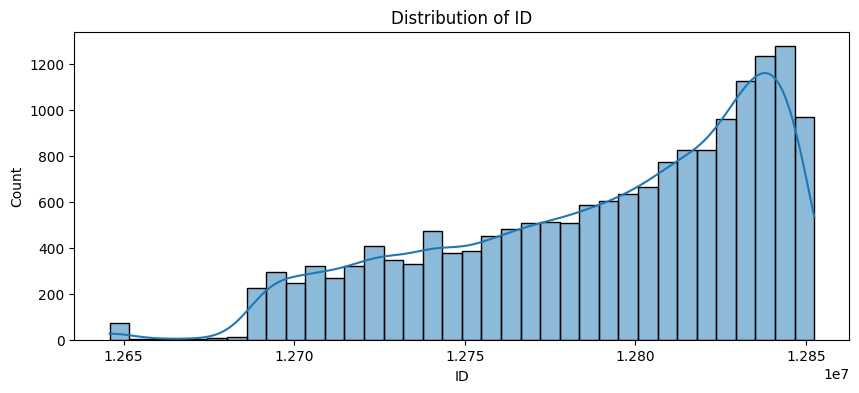

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


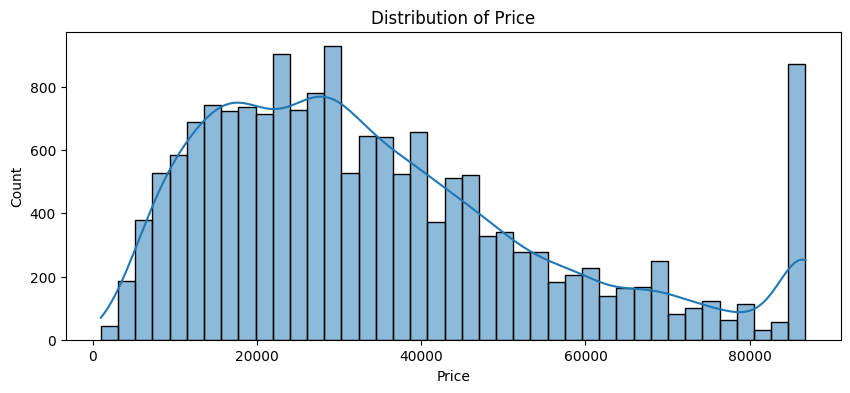

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


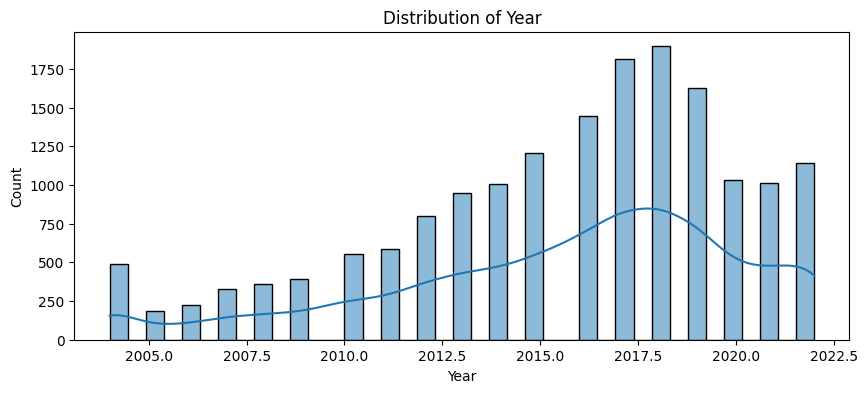

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


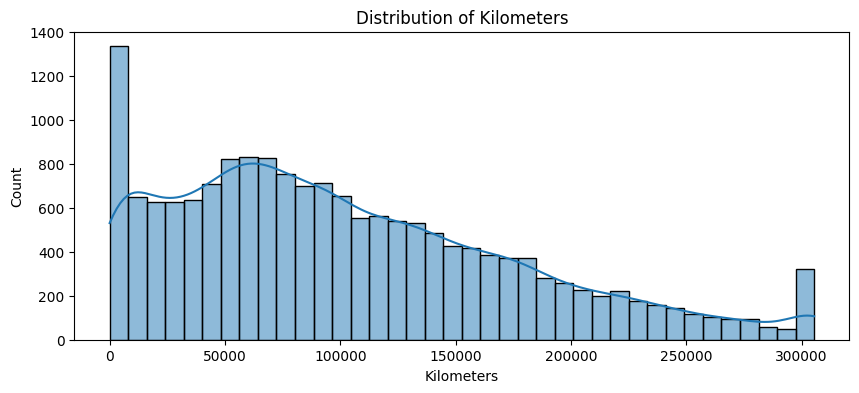

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


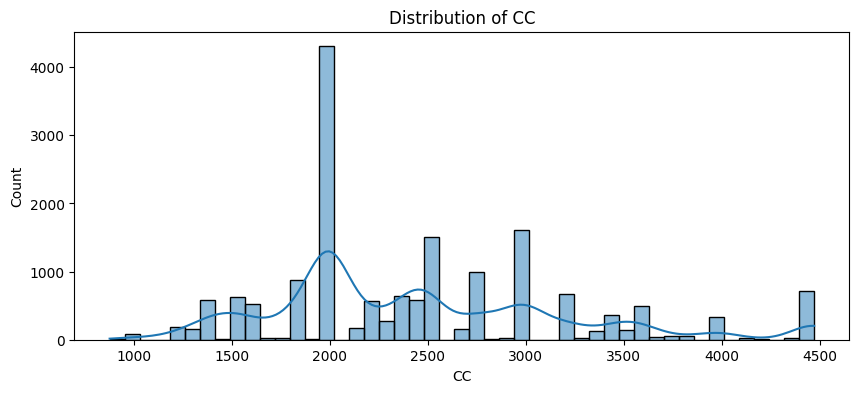

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


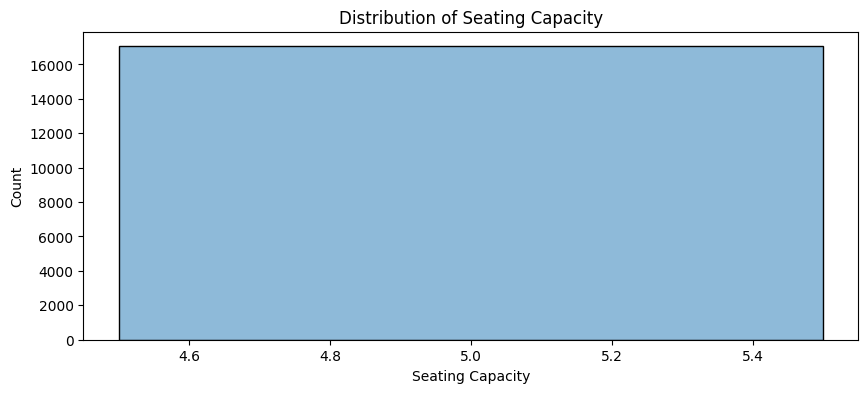

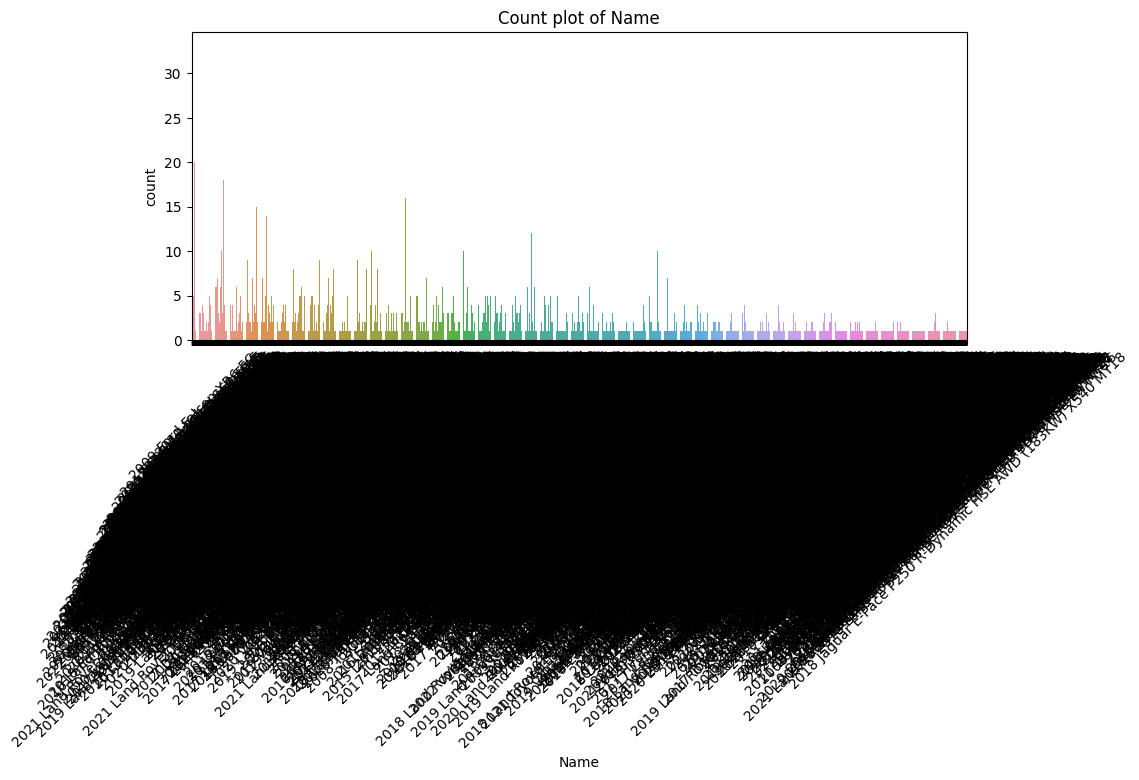

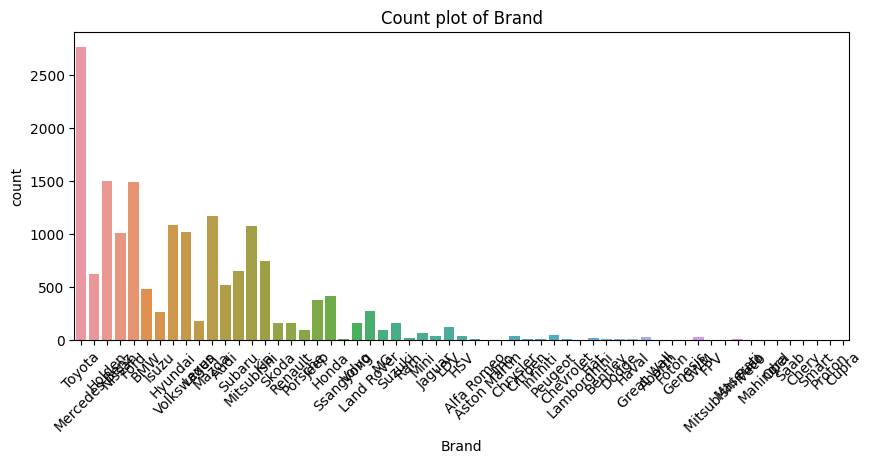

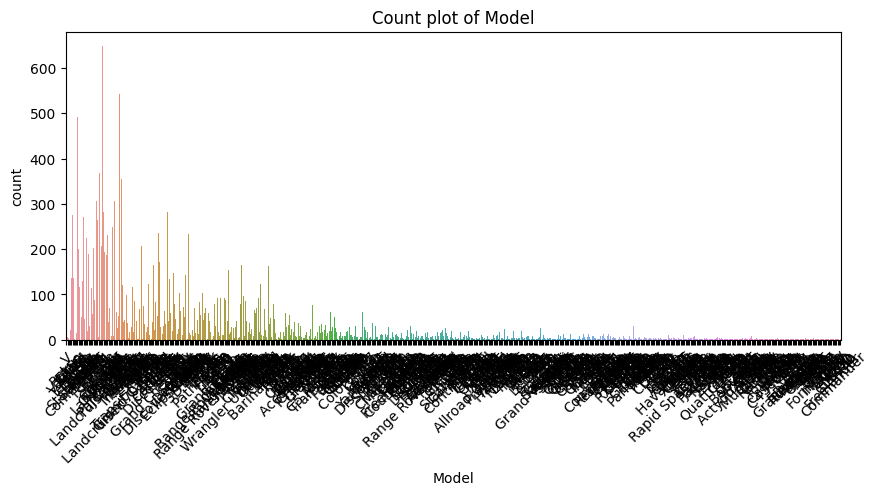

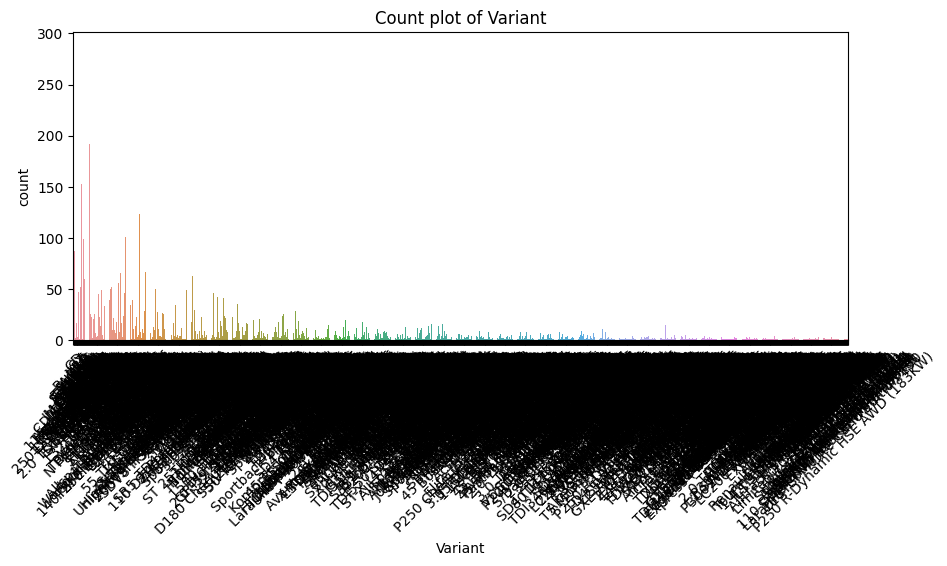

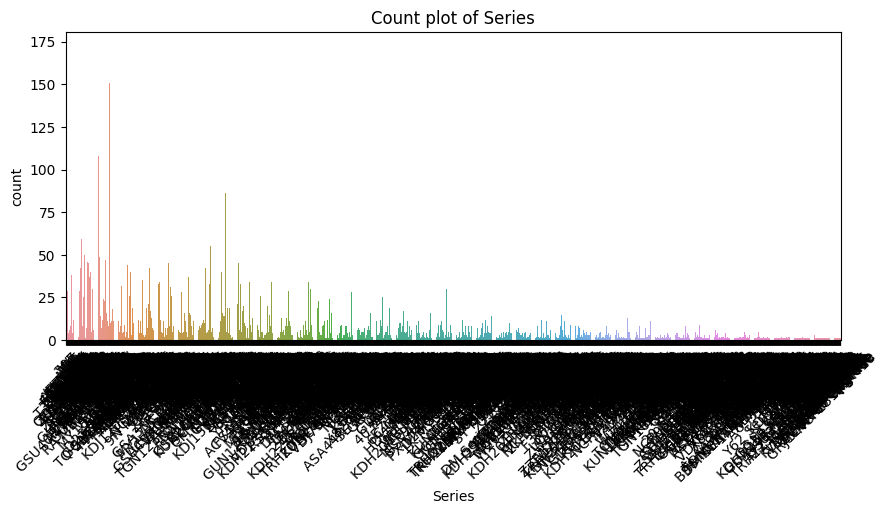

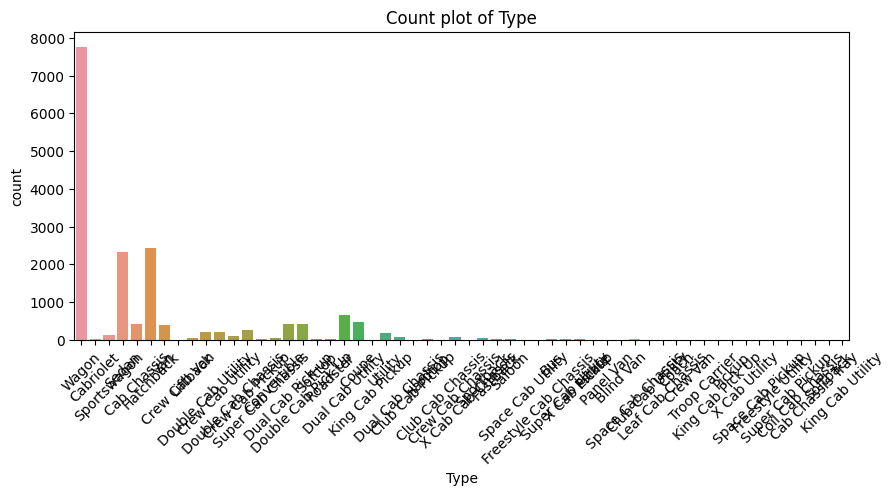

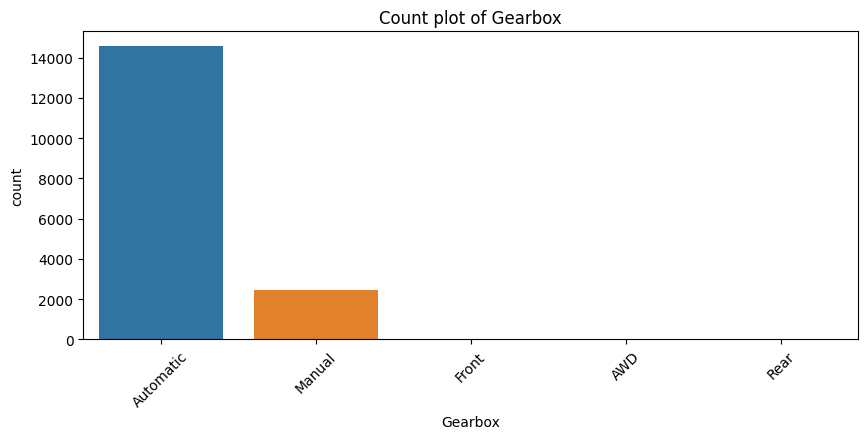

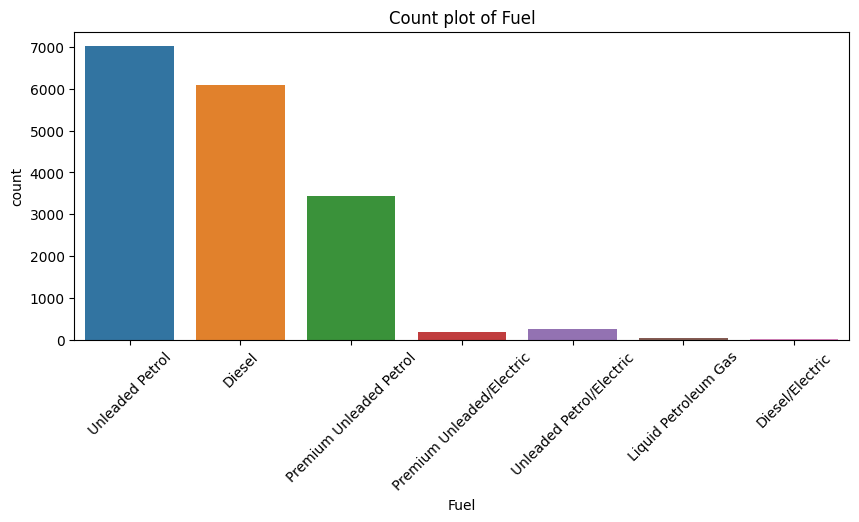

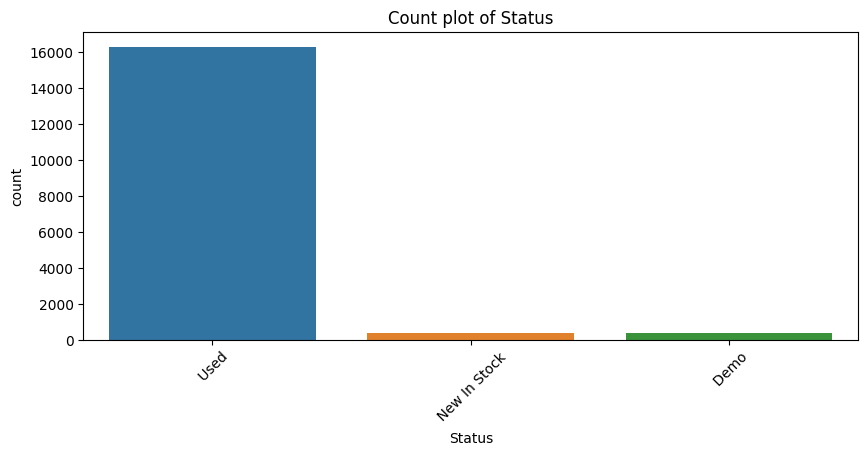

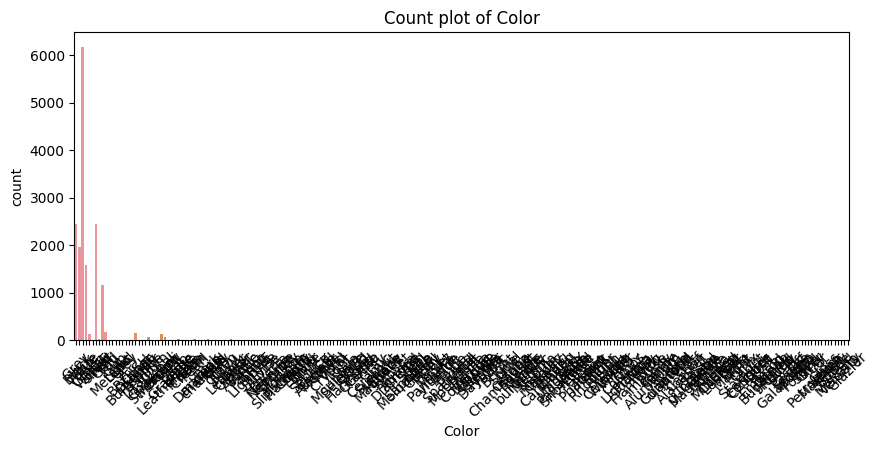

Correlation with ID variable:
Year                0.000041
Kilometers         -0.008748
Price              -0.065347
CC                 -0.072608
Seating Capacity         NaN
Name: ID, dtype: float64


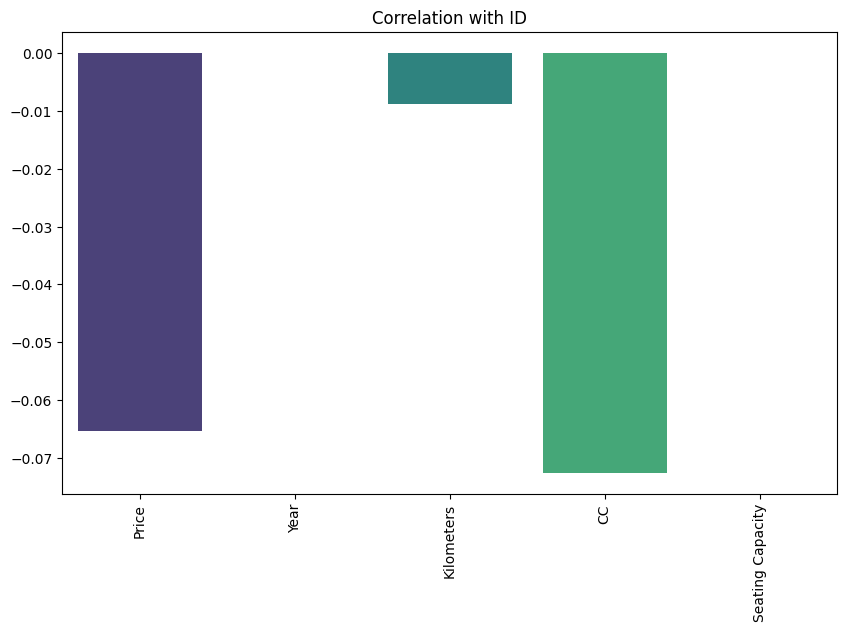

In [9]:
# 2 B)
numerical_vars = df.select_dtypes(include=['int64','float64'])
for col in numerical_vars.columns:
    plt.figure(figsize=(10,4))
    sns.histplot(df[col],kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()
    
categorical_vars = df.select_dtypes(include=['object','category'])
for col in categorical_vars.columns:
    plt.figure(figsize=(10,4))
    sns.countplot(x=df[col])
    plt.title(f'Count plot of {col}')
    plt.xticks(rotation=45)
    plt.show()
    
    
ID = 'ID'
if ID in df.columns:
    df_numerical = df.select_dtypes(include=['int64','float64'])
    correlations = df_numerical.corr()[ID].drop(ID)
    
    print("Correlation with ID variable:")
    print(correlations.sort_values(ascending=False))
    plt.figure(figsize=(10,6))
    sns.barplot(x=correlations.index,y=correlations.values, palette='viridis')
    plt.title(f'Correlation with {ID}')
    plt.xticks(rotation=90)
    plt.show()

In [10]:
# 2 C)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
variables_to_exclude = ['Name','Brand']
df_cleaned = df.drop(columns=variables_to_exclude)

ID = 'ID'
if ID in df_cleaned.columns:
    x = df_cleaned.drop(columns=[ID])
    y = df_cleaned[ID]
    
    x_train,x_test,y_trai,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
    
    scaler = StandardScaler()
    numerical_features = x_train.select_dtypes(include=['int64','float64']).columns
    x_train[numerical_features] = scaler.fit_transform(x_train[numerical_features])
    x_test[numerical_features] = scaler.transform(x_test[numerical_features])
    
    print("Data preparation complete. the dataset is now ready for model creation.")
    

Data preparation complete. the dataset is now ready for model creation.


In [11]:
# 2 D)
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

categorical_vars = df.select_dtypes(include=['object','category']).columns

label_encoders = {}
for col in categorical_vars:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    
print("Label Encoding completed.")

df_encoded = pd.get_dummies(df,columns=categorical_vars,drop_first=True)
print("One-Hot Encoding completed.")


preprocessor = ColumnTransformer(
transformers=[
    ('cat', OneHotEncoder(drop='first'), categorical_vars)
    
],
remainder='passthrough')

x = preprocessor.fit_transform(df)
print("ColumnTransformer completed.")

Label Encoding completed.
One-Hot Encoding completed.
ColumnTransformer completed.


In [12]:
# 2 E)
from sklearn.model_selection import train_test_split
from scipy import stats

ID = 'ID'
if ID in df.columns:
    x = df.drop(columns=[ID])
    y=df[ID]
    
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3, random_state=42)
    def compare_distributions(df1,df2,columns):
        for col in columns:
            if df1[col].dtype in ['int64','float64']:
                _,p_value = stats.ks_2samp(df1[col],df2[col])
                print(f"Kolmogorov-SMirnov test p-value for {col}: {p_value:.4f}")
                if p_value <0.05:
                    print(f"Distribution of {col} is significantly different between training and testing sets.")
                else:
                    print(f"Distribution of {col} is similar between training and testing sets.")
            else:
                contingency = pd.crosstab(df1[col], df2[col])
                _, p_value, _,_ = stats.chi2_contingency(contingency)
                print(f"Chi-square test p-value for {col}: {p_value:.4f}")
                if p_value < 0.05:
                    print(f"Distribution of {col} is significantly differen between training and testing sets.")
                else:
                    print(f"Distribution of {col} is similar between training and testing sets.")
    compare_distributions(pd.concat([x_train,y_train], axis=1), pd.concat([x_test,y_test], axis=1), x.columns)



Kolmogorov-SMirnov test p-value for Name: 0.2335
Distribution of Name is similar between training and testing sets.
Kolmogorov-SMirnov test p-value for Price: 0.6028
Distribution of Price is similar between training and testing sets.
Kolmogorov-SMirnov test p-value for Brand: 0.0611
Distribution of Brand is similar between training and testing sets.
Kolmogorov-SMirnov test p-value for Model: 0.1686
Distribution of Model is similar between training and testing sets.
Kolmogorov-SMirnov test p-value for Variant: 0.7956
Distribution of Variant is similar between training and testing sets.
Kolmogorov-SMirnov test p-value for Series: 0.6322
Distribution of Series is similar between training and testing sets.
Kolmogorov-SMirnov test p-value for Year: 0.6107
Distribution of Year is similar between training and testing sets.
Kolmogorov-SMirnov test p-value for Kilometers: 0.2435
Distribution of Kilometers is similar between training and testing sets.
Kolmogorov-SMirnov test p-value for Type: 0.

In [13]:
# 3 A)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
    
ID = 'ID '

if ID in df.columns:
    x = df.drop(columns=[ID])
    y=df[ID]
    
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)
    model = LogisticRegression(max_iter=1000)
    model.fit(x_train,y_train)
    
    y_pred = model.predict(x_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test,y_pred)
    print(f"Accuarcy of Logistic regression model: {accuracy:.4f}")
    print("Classification Report:")
    print(report)
    
    

In [14]:
# 3 A)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

ID = 'ID'
if ID in df.columns:
    x=df.drop(columns=[ID])
    y=df[ID]
    
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)
    
    model = LinearRegression()
    model.fit(x_train,y_train)
    
    y_pred = model.predict(x_test)
    mse = mean_squared_error(y_test,y_pred)
    r2 = r2_score(y_test,y_pred)
    
    print(f"Mean squared error of Linear Regression model: {mse:.4f}")
    print(f"R^2 score of linear regression model: {r2:.4f}")
    
    
   


Mean squared error of Linear Regression model: 2152891436.4640
R^2 score of linear regression model: 0.0137


In [15]:
# 3 B)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

ID = 'ID'
if ID in df.columns:
    x = df.drop(columns=[ID])
    y=df[ID]
    
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)
    
    model = LogisticRegression(max_iter=1000)
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test,y_pred)
    print(f"Overall accuracy of the Logistic Regression model: {accuracy:.4f}")
    

ValueError: Unknown label type: 'continuous'

In [ ]:
# 3 B)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

ID = 'ID'
if ID in df.columns:
    x=df.drop(columns=[ID])
    y=df[ID]
    
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)
    
    model = LinearRegression()
    model.fit(x_train,y_train)
    
    y_pred = model.predict(x_test)
    mse = mean_squared_error(y_test,y_pred)
    r2 = r2_score(y_test,y_pred)
    
    print(f"Mean squared error of Linear Regression model: {mse:.4f}")
    print(f"R^2 score of linear regression model: {r2:.4f}")
    
    


In [ ]:
# 3 C)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report

ID = 'ID'
if ID in df.columns:
    x = df.drop(columns=[ID])
    y = [ID]
    
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)
    model = LinearRegression()
    model.fit(x_train,y_train)
    
    y_pred = model.predict(x_test)
    
    report = classification_report(y_test,y_pred,target_names=['Class 0','Class 1'])
    print("Classification Report:")
    print(report)
    
    y_prob = model.predict_proba(x_test)[:,1]
    precision,recall, _ = precision_recall_curve(y_test,y_prob)
    
    plt.figure()
    plt.plot(recall,precision,marker='.')
    plt.xlabel('Recall')
    plt.ylabel('precision')
    plt.title('Precision-RecallCurve')
    plt.show()
    f1 = f1_score(y_test,y_pred,average=None)
    print(f"F1 score for each class: {f1}")
    
    

In [ ]:
# 3 C)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score,precision_recall_curve

ID = 'ID'
if ID in df.columns:
    x = df.drop(columns=[ID])
    y = [ID]
    
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)
    
    model = LogisticRegression(max_iter=1000)
    model.fit(x_train,y_train)
    
    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:,1]
    
    precision = precision_score(y_test,y_pred)
    recall = recall_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 score: {f1:.4f}")
    
    
    report = classification_report(y_test,y_pred)
    print("Classification Report:")
    print(report)
    
    precision_vals, recall_vals,_ = precision_recall_curve(y_test,y_prob)
    plt.figure()
    plt.plot(recall,precision,marker='.')
    plt.xlabel('Recall')
    plt.ylabel('precision')
    plt.title('Precision-RecallCurve')
    plt.show()
    
    

In [ ]:
# 3 D)

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

ID = 'ID'
categorical_columns= ['Name','Brand']
numerical_columns = ['Price','Series']

if ID in df.columns:
    x = df.drop(columns=[ID])
    y = df[ID]
    
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)
    
    numeric_transformer = Pipeline(steps=[
        ('scaler', StandardScaler())
    ])
    
    categorical_transformer = Pipeline(steps=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])
    
    preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_columns),
        ('cat', categorical_transformer, categorical_columns)
    ])
    
    
    model = RandomForestClassifier(random_state=42)
    clf = Pipeline(steps=[('preprocessor', preprocessor),
                         ('classifier',model)])
    param_grid = {
        'classifier_n_estimators':[50,100,200],
        'classifier_max_depth':[None, 10,20,30],
        'classifier_min_samples_split':[2,5,10]
    }
    
    grid_search = GridSearchCV(clf,param_grid,cv=5,scoring='accuracy')
    grid_search.fit(x_train,y_train)
    
    print(f"Best parameters: {grid_search.best_params_}")
    
    y_pred = grid_search.best_estimator_.predict(x_test)
    print("Classification Report:")
    print(classification_report(y_test,y_pred))
    

In [ ]:
df.head()

In [ ]:
# 3 E)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import shap

ID = 'ID'
categorical_columns= ['Name','Brand']
numerical_columns = ['Price','Series']

if ID in df.columns:
    x = df.drop(columns=[ID])
    y = df[ID]
    
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)
    
    model = RandomForestClassifier(random_state=42)
    model.fit(x_train,y_train)
    
    y_pred = model.predict(x_test)
    print("Classification Report:")
    print(classification_report(y_test,y_pred))
    
    feature_importances = model.feature_importances_
    feature_names = x.columns
    importance_df = pd.DataFrame({'Feature': feature_names,'Importance': feature_importances})
    importance_df = importance_df.sort_values(by='Importances',ascending=False)
    
    plt.figure(figsize=(10,6))
    plt.barh(importance_df['Feature'], importance_df['Importance'])
    plt.gca().invert_yaxis()
    plt.xlabel('Importance')
    plt.title('Feature Importances from random forest')
    plt.show()
    
    explainer = shap.Explainer(model,x_train)
    shap_values =explainer(x_test)
    
    shap.summary_plot(shap_values,x_test, plot_type='bar')
    shap.summary_plot(shap_values,x_test)
    